# Part 1

In [2]:
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('OG used_car_prices.csv')

In [6]:
df

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558832,2015,Kia,K900,Luxury,Sedan,NaN,knalw4d4xf6019304,in,45.0,18255.0,silver,black,avis corporation,35300.0,33000.0,Thu Jul 09 2015 07:00:00 GMT-0700 (PDT)
558833,2012,Ram,2500,Power Wagon,Crew Cab,automatic,3c6td5et6cg112407,wa,5.0,54393.0,white,black,i -5 uhlmann rv,30200.0,30800.0,Wed Jul 08 2015 09:30:00 GMT-0700 (PDT)
558834,2012,BMW,X5,xDrive35d,SUV,automatic,5uxzw0c58cl668465,ca,48.0,50561.0,black,black,financial services remarketing (lease),29800.0,34000.0,Wed Jul 08 2015 09:30:00 GMT-0700 (PDT)
558835,2015,Nissan,Altima,2.5 S,sedan,automatic,1n4al3ap0fc216050,ga,38.0,16658.0,white,black,enterprise vehicle exchange / tra / rental / t...,15100.0,11100.0,Thu Jul 09 2015 06:45:00 GMT-0700 (PDT)


In [8]:
df.isnull().sum()

year                0
make            10301
model           10399
trim            10651
body            13195
transmission    65352
vin                 4
state               0
condition       11820
odometer           94
color             749
interior          749
seller              0
mmr                38
sellingprice       12
saledate           12
dtype: int64

In [10]:
df.dropna(inplace=True)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 472325 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          472325 non-null  int64  
 1   make          472325 non-null  object 
 2   model         472325 non-null  object 
 3   trim          472325 non-null  object 
 4   body          472325 non-null  object 
 5   transmission  472325 non-null  object 
 6   vin           472325 non-null  object 
 7   state         472325 non-null  object 
 8   condition     472325 non-null  float64
 9   odometer      472325 non-null  float64
 10  color         472325 non-null  object 
 11  interior      472325 non-null  object 
 12  seller        472325 non-null  object 
 13  mmr           472325 non-null  float64
 14  sellingprice  472325 non-null  float64
 15  saledate      472325 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 61.3+ MB


In [14]:
from datetime import datetime
import re
from dateutil.relativedelta import relativedelta

# Function to parse date by handling time zones and add 1 year
def parse_and_add_year(date_str):
    # Remove the time zone abbreviation (e.g., "(PST)") using regex
    clean_str = re.sub(r"\s\([A-Z]+\)$", "", date_str)
    # Parse the cleaned string and add 1 year
    return datetime.strptime(clean_str, "%a %b %d %Y %H:%M:%S GMT%z").date() + relativedelta(years=1)

# Apply the function to each entry in the 'saledate' column
df['saledate'] = df['saledate'].apply(parse_and_add_year)


In [15]:
df.loc[:, 'state'] = df['state'].str.upper()

In [18]:
df['price deviation'] = df['sellingprice']-df['mmr']

In [20]:
# Calculate the color counts and exclude '-'
color_counts = df['color'].value_counts()
color_counts_without_dash = color_counts.drop('—')

# Calculate the proportions without '-'
color_proportions_without_dash = color_counts_without_dash / color_counts_without_dash.sum()

# Number of '-' rows to be distributed
num_dash_rows = color_counts['—']

# Calculate how many of the '-' rows should go to each color
distribution_counts = (color_proportions_without_dash * num_dash_rows).round().astype(int)

import numpy as np

# Get the indices of rows with color '-'
dash_indices = df[df['color'] == '—'].index

# Create a list of new color values for '-' rows
new_colors = []
for color, count in distribution_counts.items():
    new_colors.extend([color] * count)

# In case of rounding discrepancies, adjust the length of new_colors
new_colors = new_colors[:len(dash_indices)]

# Assign new colors to rows that previously had '-'
df.loc[dash_indices, 'color'] = np.random.choice(new_colors, size=len(dash_indices), replace=True)

In [22]:
df.columns

Index(['year', 'make', 'model', 'trim', 'body', 'transmission', 'vin', 'state',
       'condition', 'odometer', 'color', 'interior', 'seller', 'mmr',
       'sellingprice', 'saledate', 'price deviation'],
      dtype='object')

In [24]:
# Set pandas to display all rows

# Show the value counts for the 'model' column
print(df['body'].nunique())

85


In [26]:
df['body'] = df['body'].str.lower()

In [28]:
# Show the value counts for the 'model' column
print(df['body'].nunique())

45


In [30]:
# Summary statistics for 'condition' column
print(df['condition'].describe())

count    472325.000000
mean         30.774177
std          13.286866
min           1.000000
25%          24.000000
50%          35.000000
75%          41.000000
max          49.000000
Name: condition, dtype: float64


In [32]:
# Unique values and their frequency
print(df['condition'].value_counts().sort_index())

condition
1.0      5805
2.0     17248
3.0      9190
4.0     17078
5.0      9414
11.0       79
12.0       86
13.0       74
14.0      116
15.0      116
16.0      151
17.0      209
18.0      290
19.0    36647
21.0     8002
22.0     5235
23.0     7131
24.0     8154
25.0    10943
26.0    10370
27.0    14173
28.0    16650
29.0    16433
31.0     7942
32.0     8654
33.0     9176
34.0    15096
35.0    23209
36.0    20164
37.0    22680
38.0    16393
39.0    17567
41.0    19889
42.0    21094
43.0    21593
44.0    22091
45.0    10688
46.0    10822
47.0     9743
48.0    10884
49.0    11046
Name: count, dtype: int64


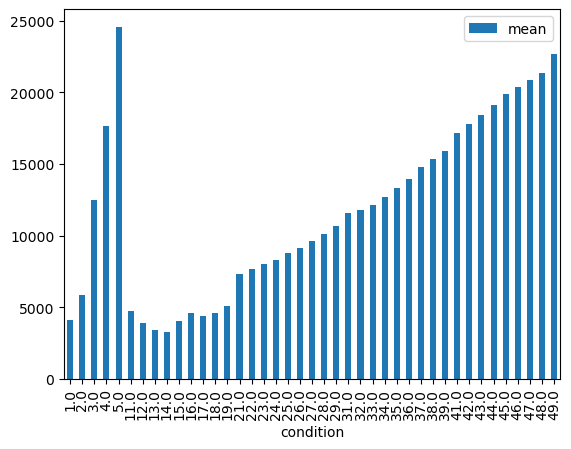

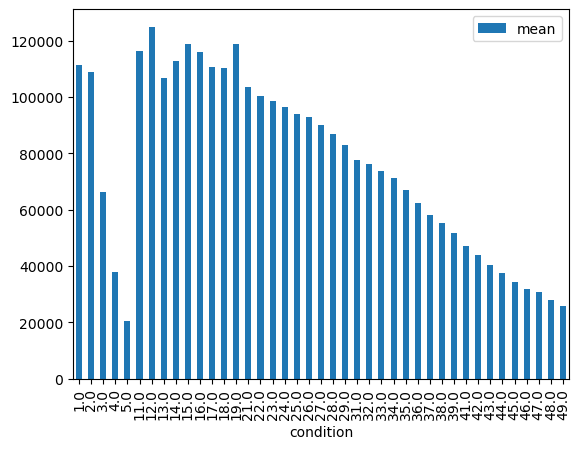

In [34]:
df.groupby('condition')['sellingprice'].agg(['mean']).plot(kind='bar')
plt.show()
df.groupby('condition')['odometer'].agg(['mean']).plot(kind='bar')
plt.show()

In [36]:
score= [1,2,3,4,5]
    
df5 = df[df['condition'].isin(score)]

<Axes: xlabel='saledate'>

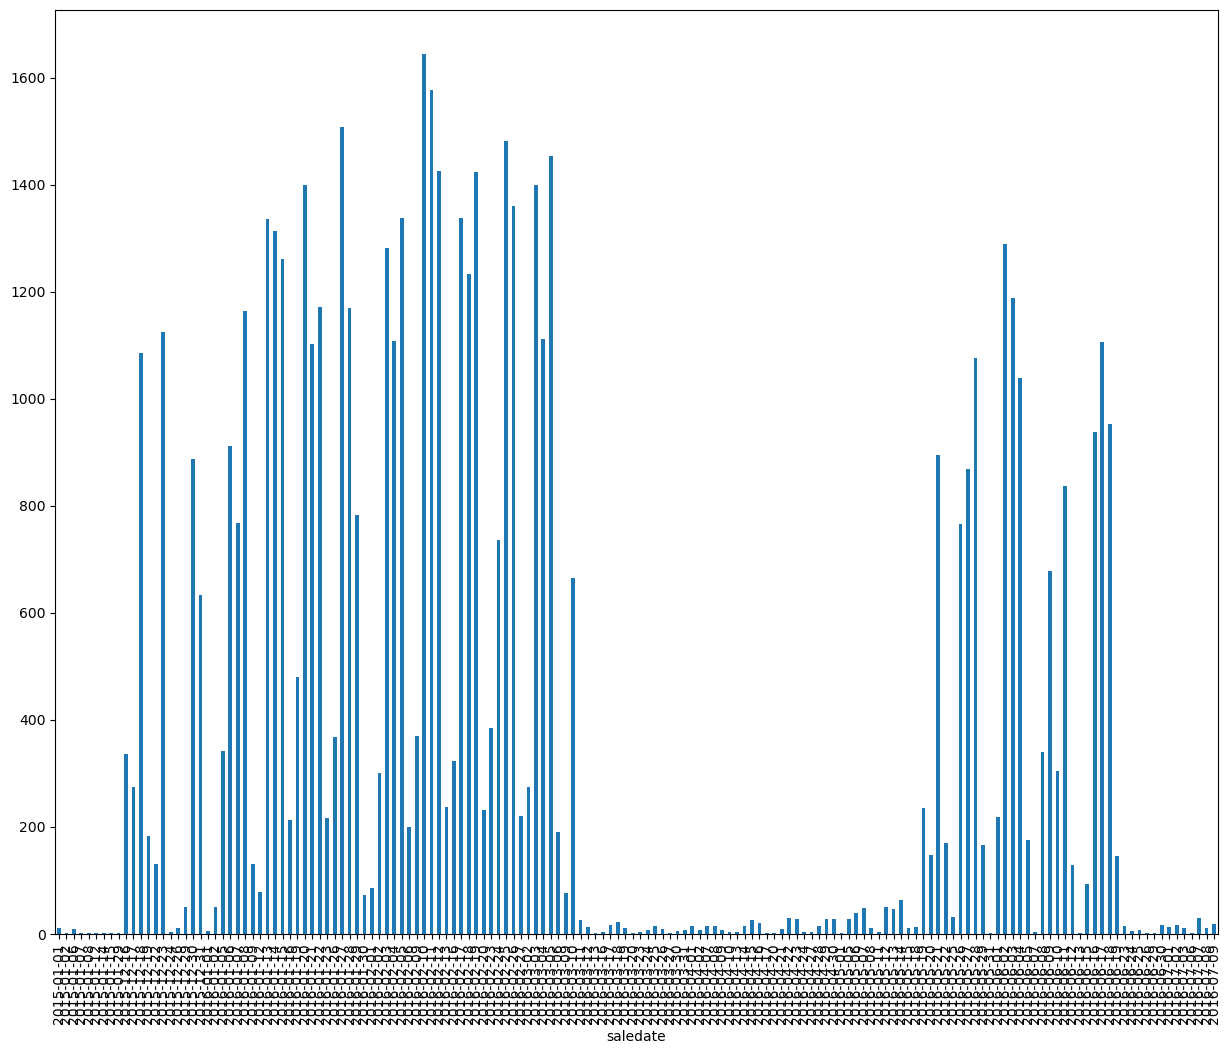

In [38]:
df5['saledate'].value_counts().sort_index().plot(kind='bar', figsize=(15,12))

In [40]:
# Ensure that the 'saledate' column is of datetime type
df['saledate'] = pd.to_datetime(df['saledate'])

# Filter out rows where 'saledate' is before '2015-12-10' and 'condition' is greater than 5
df = df[(df['saledate'] >= '2015-12-10') & (df['condition'] > 5)]

# Create a new column 'used years'
df['used years'] = df['saledate'].dt.year - df['year']

# Create a new column 'weekday' with values from 1 (Monday) to 7 (Sunday)
df['weekday'] = df['saledate'].dt.weekday + 1

/var/folders/dw/d5lslwns7d7_2xfqkh_nd27w0000gn/T/ipykernel_4680/1687681527.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['used years'] = df['saledate'].dt.year - df['year']
/var/folders/dw/d5lslwns7d7_2xfqkh_nd27w0000gn/T/ipykernel_4680/1687681527.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['weekday'] = df['saledate'].dt.weekday + 1


<Axes: xlabel='saledate'>

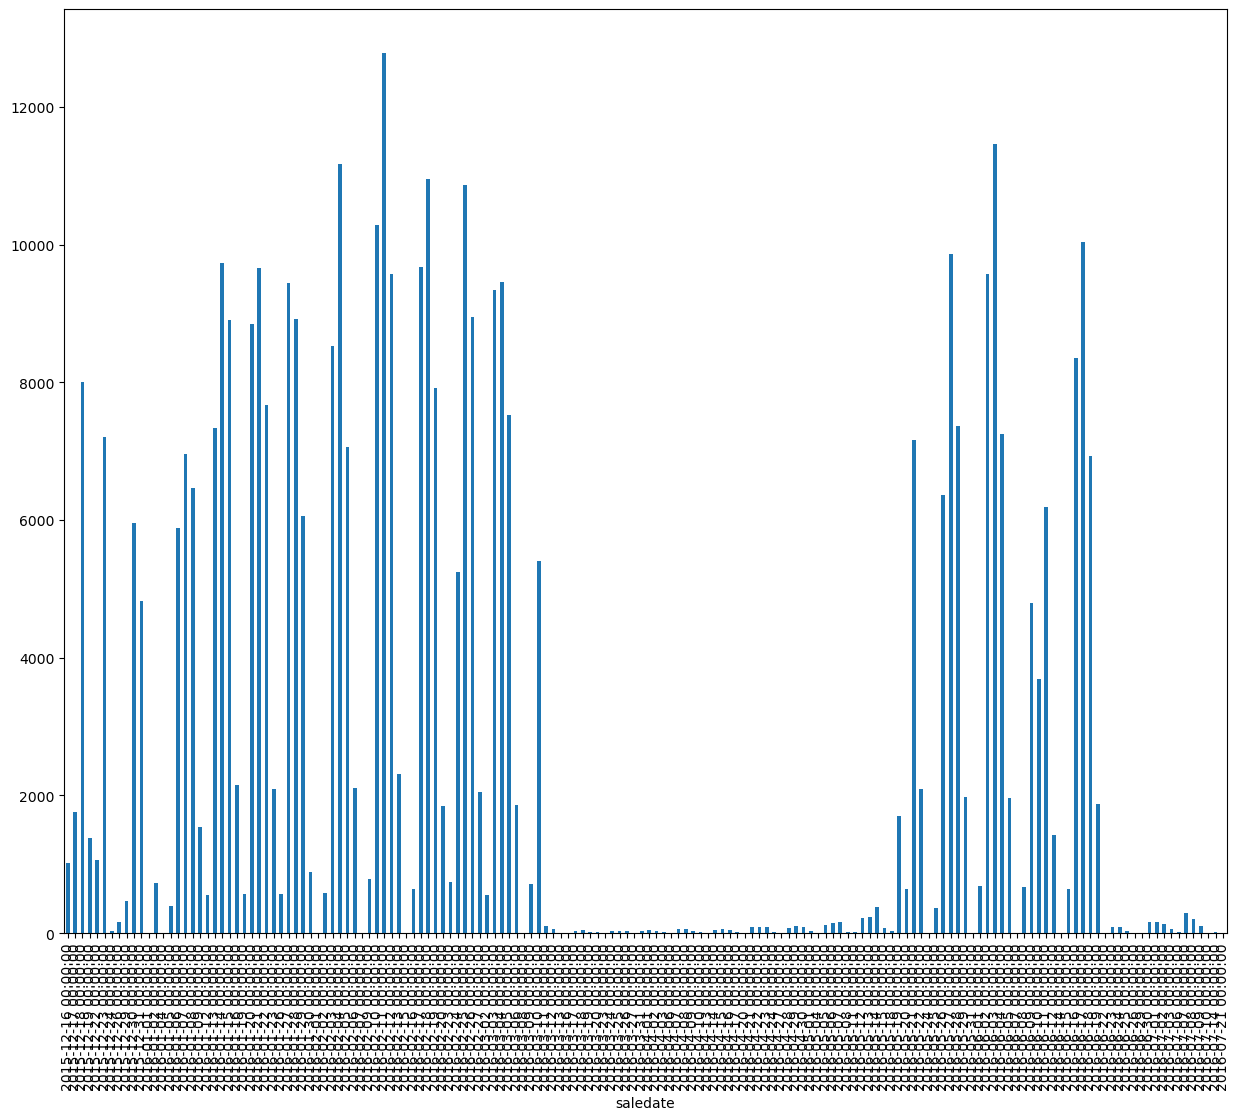

In [42]:
df['saledate'].value_counts().sort_index().plot(kind='bar', figsize=(15,12))

In [44]:
# Unique values and their frequency
print(df['condition'].value_counts().sort_index())

condition
11.0       79
12.0       86
13.0       74
14.0      116
15.0      115
16.0      150
17.0      209
18.0      289
19.0    36636
21.0     8000
22.0     5235
23.0     7130
24.0     8154
25.0    10941
26.0    10370
27.0    14168
28.0    16645
29.0    16433
31.0     7941
32.0     8653
33.0     9173
34.0    15091
35.0    23204
36.0    20160
37.0    22676
38.0    16388
39.0    17566
41.0    19881
42.0    21085
43.0    21587
44.0    22077
45.0    10677
46.0    10807
47.0     9734
48.0    10865
49.0    11036
Name: count, dtype: int64


/var/folders/dw/d5lslwns7d7_2xfqkh_nd27w0000gn/T/ipykernel_4680/1491119654.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['condition level'] = pd.cut(df['condition'], bins=bins, labels=labels, right=True)


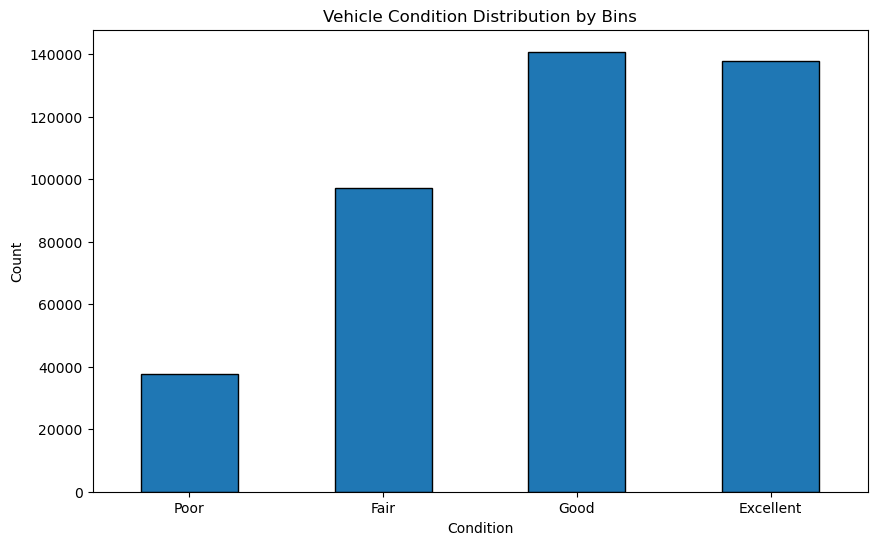

In [48]:
import matplotlib.pyplot as plt

# Define bins and labels based on the condition range and distribution
bins = [10, 20, 30, 40, 50]
labels = ['Poor', 'Fair', 'Good', 'Excellent']

# Bin the data in the 'condition' column
df['condition level'] = pd.cut(df['condition'], bins=bins, labels=labels, right=True)

# Count the occurrences in each bin
condition_counts = df['condition level'].value_counts().sort_index()

# Plot the bar chart
plt.figure(figsize=(10, 6))
condition_counts.plot(kind='bar', edgecolor='black')
plt.title('Vehicle Condition Distribution by Bins')
plt.xlabel('Condition')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()



In [50]:
df.groupby('condition level')[['sellingprice', 'price deviation']].agg(['mean', 'median']).round(2).sort_index(ascending=False)

/var/folders/dw/d5lslwns7d7_2xfqkh_nd27w0000gn/T/ipykernel_4680/2518069385.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('condition level')[['sellingprice', 'price deviation']].agg(['mean', 'median']).round(2).sort_index(ascending=False)


sellingprice          price deviation       
                        mean   median            mean median
condition level                                             
Excellent           19265.71  17000.0          375.63  300.0
Good                13862.72  12400.0           36.32   50.0
Fair                 9207.02   8000.0         -513.42 -400.0
Poor                 5081.83   3600.0        -1056.11 -775.0

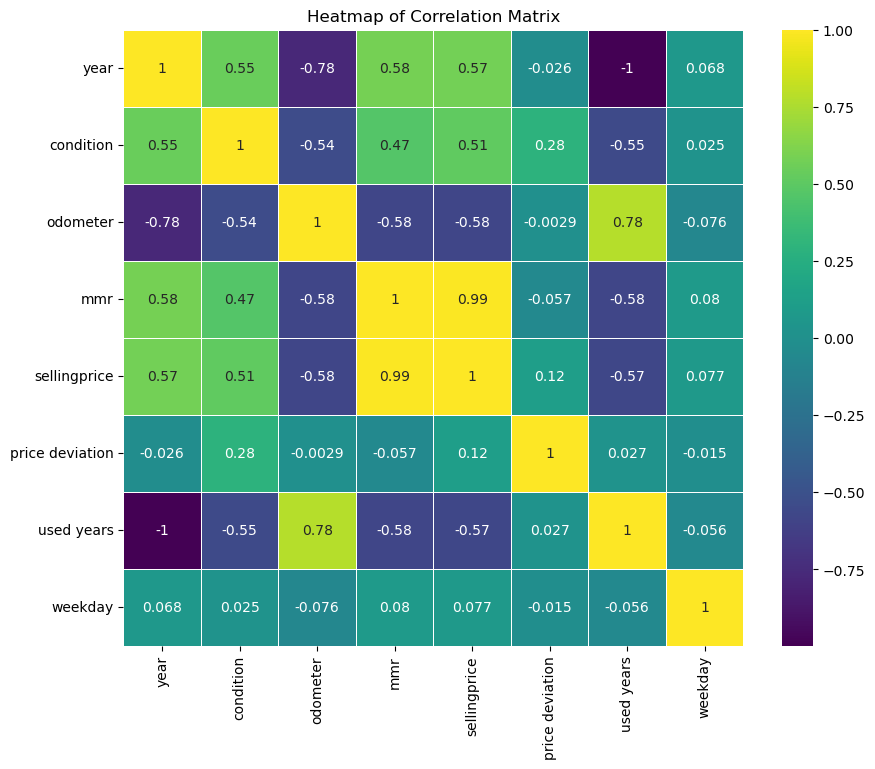

In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df_n = df.select_dtypes(['float64', 'int64','int32'])

# Calculate the correlation matrix
corr_matrix = df_n.corr()

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Create the heatmap using seaborn
sns.heatmap(corr_matrix, annot=True, cmap='viridis', linewidths=0.5)

# Add labels and title
plt.title('Heatmap of Correlation Matrix')
plt.show()


In [54]:
# List the columns in the desired order
new_column_order = ['vin', 'make', 'model','year', 'body', 'transmission',  
       'condition','condition level', 'odometer', 'color', 'interior','state', 'used years', 'seller', 'mmr',
       'sellingprice','price deviation', 'saledate', 'weekday']

# Reorder the DataFrame columns
df = df[new_column_order]

In [68]:
# Take a 10% random sample of the data
df_sampled = df.sample(frac=0.15, random_state=2)


In [70]:
df_sampled

,vin,make,model,year,body,transmission,condition,condition level,odometer,color,interior,state,used years,seller,mmr,sellingprice,price deviation,saledate,weekday
58262,1gcgg25v561172828,Chevrolet,Express Cargo,2006,van,automatic,24.0,Fair,65767.0,white,beige,MO,10,manheim st louis,6625.0,6600.0,-25.0,2016-01-13,3
220754,2fmdk3jc4cba94033,Ford,Edge,2012,suv,automatic,21.0,Fair,35963.0,silver,black,CA,4,ge fleet services for itself/servicer,19800.0,17500.0,-2300.0,2016-02-05,5
302833,3tmju4gn1bm121928,Toyota,Tacoma,2011,double cab,automatic,48.0,Excellent,51885.0,blue,gray,CA,5,aaero sweet company,20700.0,25000.0,4300.0,2016-02-12,5
141258,4s3bmbg69a3228498,Subaru,Legacy,2010,sedan,automatic,28.0,Fair,107227.0,red,black,NV,6,remarketing by ge/manheim nevada,6750.0,8700.0,1950.0,2016-01-16,6
394997,1gnskbe0xcr166282,Chevrolet,Tahoe,2012,suv,automatic,41.0,Excellent,57624.0,silver,beige,CA,4,aaero sweet corporation,26700.0,29500.0,2800.0,2016-03-05,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133735,wddhf5kb3da723506,Mercedes-Benz,E-Class,2013,sedan,automatic,37.0,Good,22724.0,gray,gray,CA,3,mercedes-benz financial services,32300.0,33250.0,950.0,2016-01-15,5
207756,1gkfk66u85j107692,GMC,Yukon XL,2005,suv,automatic,35.0,Good,128473.0,gray,gray,CA,11,nvp remarketing,7200.0,8700.0,1500.0,2016-01-27,3
231361,4a3ab56f06e009507,Mitsubishi,Galant,2006,sedan,automatic,19.0,Poor,179941.0,black,black,NC,10,cbs mitsubishi durham,1550.0,2000.0,450.0,2016-02-02,2
77143,1gcek19z17z192140,Chevrolet,Silverado 1500 Classic,2007,extended cab,automatic,28.0,Fair,135403.0,silver,gray,MN,9,luther hudson chevrolet gmc,10100.0,11300.0,1200.0,2016-01-14,4


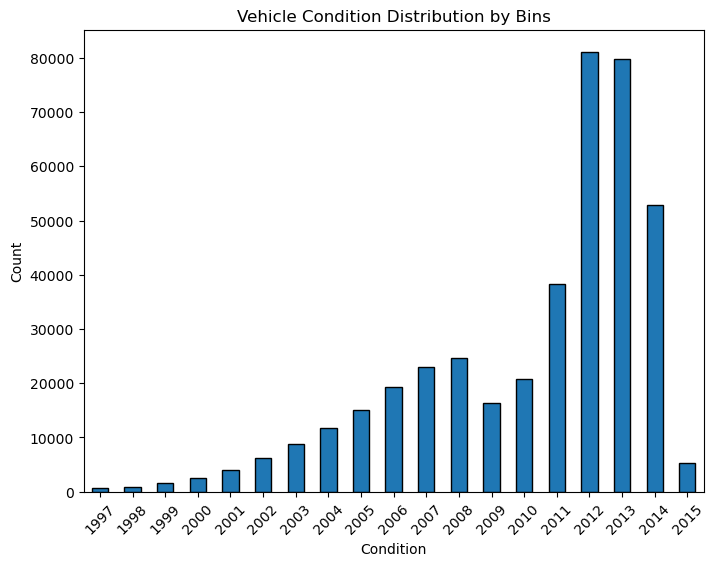

In [72]:
year_counts = df['year'].value_counts().sort_index()

# Plot the bar chart
plt.figure(figsize=(8, 6))# Define the fraction of data to keep

# Perform stratified sampling by each year and exclude grouping columns explicitly
df_sampled.groupby('year', group_keys=False, as_index=False)

year_counts.plot(kind='bar', edgecolor='black')
plt.title('Vehicle Condition Distribution by Bins')
plt.xlabel('Condition')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

<Axes: xlabel='condition level'>

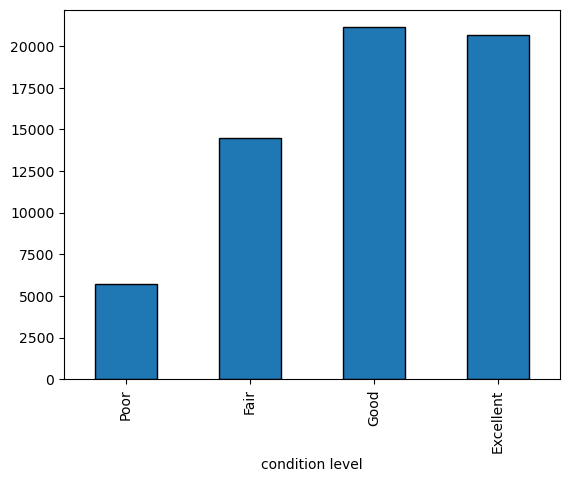

In [74]:
bin = df_sampled['condition level'].value_counts().sort_index()
bin.plot(kind='bar', edgecolor='black')


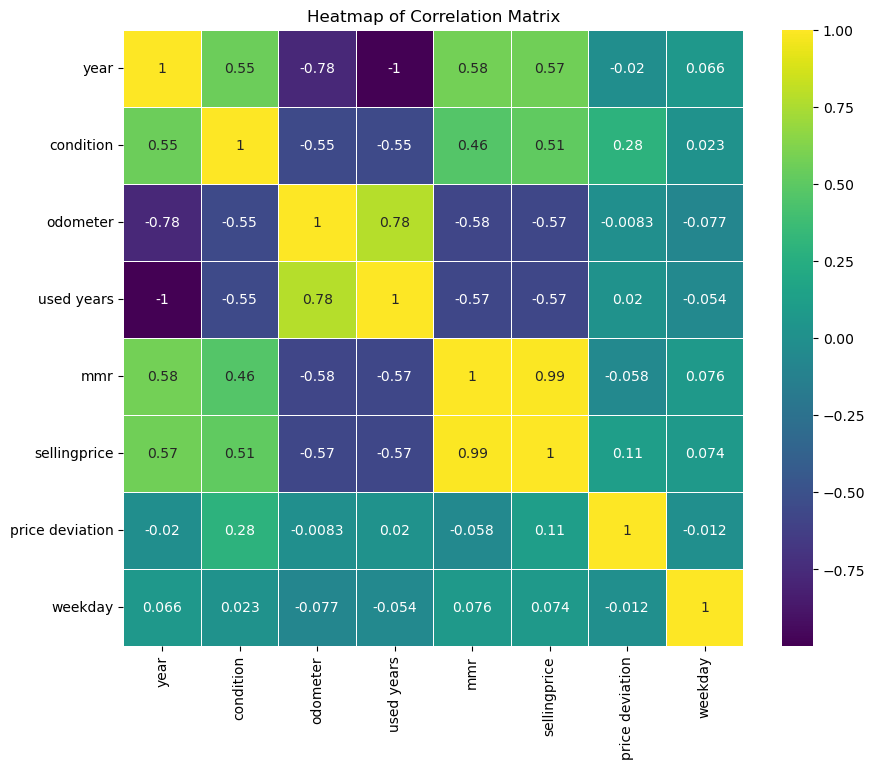

In [76]:
df_sam = df_sampled.select_dtypes(['float64', 'int64','int32'])

# Calculate the correlation matrix
corr_matrix = df_sam.corr()

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Create the heatmap using seaborn
sns.heatmap(corr_matrix, annot=True, cmap='viridis', linewidths=0.5)

# Add labels and title
plt.title('Heatmap of Correlation Matrix')
plt.show()


In [78]:
# Save DataFrame as an Excel file
df_sampled.to_csv("used_car_price.csv", index=False)


<Axes: >

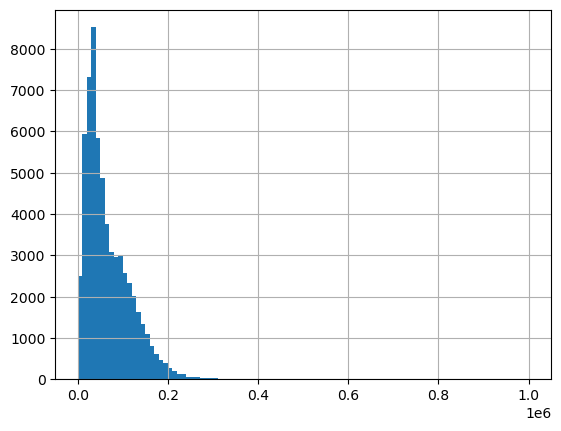

In [86]:
df_sampled['odometer'].hist(bins = 100)

In [80]:
df_sampled.groupby('seller')['price deviation'].mean().sort_values(ascending=False).head(15)

seller
mcgoldrick leasing co inc              14500.0
sports trend auto sales                12950.0
unified communities fcu                 9400.0
eautoniche llc                          8600.0
mossy toyota                            8050.0
brand automotive financial services     7700.0
moab industries                         7500.0
southeast brokerage inc                 6950.0
community united credit unoin           6900.0
lafontaine nissan inc                   6650.0
g brothers auto brokers inc             6475.0
rc motorcars                            6350.0
a & l auto sales llc                    6300.0
dan judds auto sales inc                6100.0
columbus united fcu                     6025.0
Name: price deviation, dtype: float64

# Part 2 EDA 

In [68]:
df.set_index('vin', inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 413431 entries, wba3c1c51ek116351 to 1ftfw1et2eke87277
Data columns (total 17 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   make             413431 non-null  object        
 1   model            413431 non-null  object        
 2   year             413431 non-null  int64         
 3   body             413431 non-null  object        
 4   transmission     413431 non-null  object        
 5   condition        413431 non-null  float64       
 6   condition level  413431 non-null  category      
 7   odometer         413431 non-null  float64       
 8   color            413431 non-null  object        
 9   interior         413431 non-null  object        
 10  state            413431 non-null  object        
 11  used years       413431 non-null  int64         
 12  seller           413431 non-null  object        
 13  mmr              413431 non-null  float64       
 14

In [70]:
df_num = df.select_dtypes(include=['float64','int64'])
dummy = []
for i in df.columns:
    if df[i].nunique() == 2:
        dummy.append(i)
# dummy = [] ['transmission'] not found in axis

df_cat = df.drop(df_num.columns, axis= 1)


In [72]:
df_num.describe()

,year,condition,odometer,used years,mmr,sellingprice,price deviation
count,413431.000000,413431.000000,413431.000000,413431.000000,413431.000000,413431.000000,413431.000000
mean,2010.261318,34.699609,66579.032939,5.661574,13847.336496,13767.865724,-79.470773
std,3.592571,8.794505,49533.111202,3.592191,9371.261139,9419.199163,1625.438332
min,1997.000000,11.000000,1.000000,0.000000,25.000000,1.000000,-87750.000000
25%,2008.000000,28.000000,29617.500000,3.000000,7625.000000,7500.000000,-750.000000
50%,2012.000000,36.000000,52004.000000,4.000000,12250.000000,12200.000000,0.000000
75%,2013.000000,42.000000,95693.000000,8.000000,18200.000000,18100.000000,700.000000
max,2015.000000,49.000000,999999.000000,19.000000,182000.000000,230000.000000,207200.000000


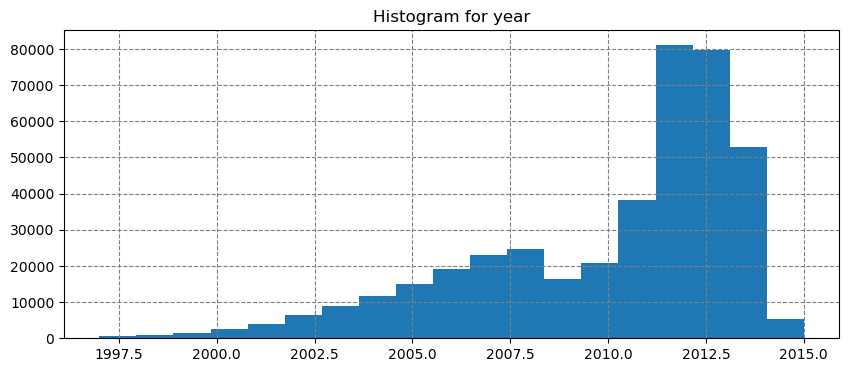

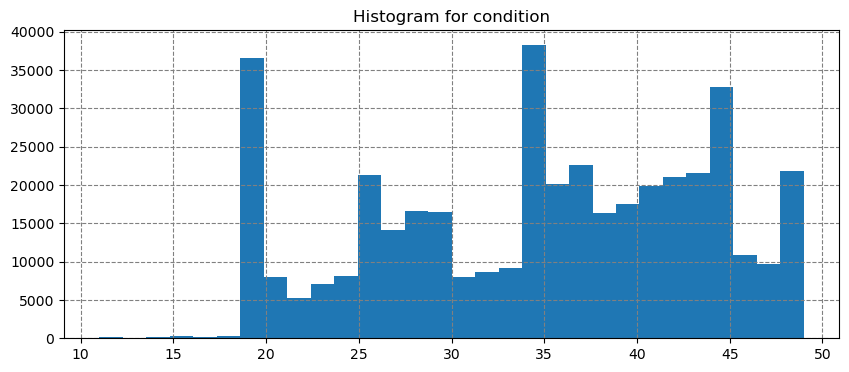

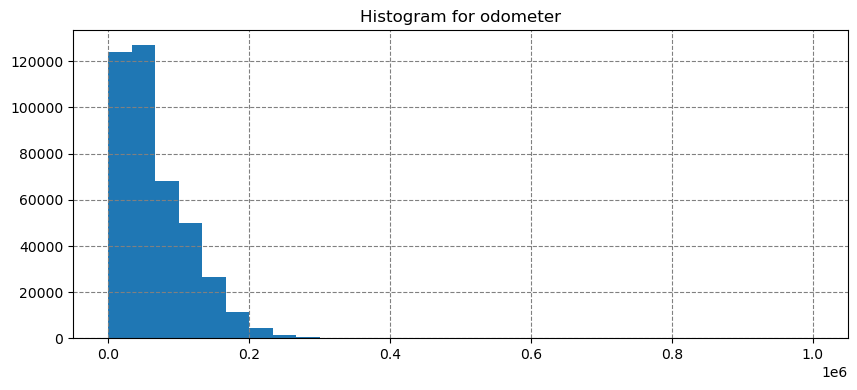

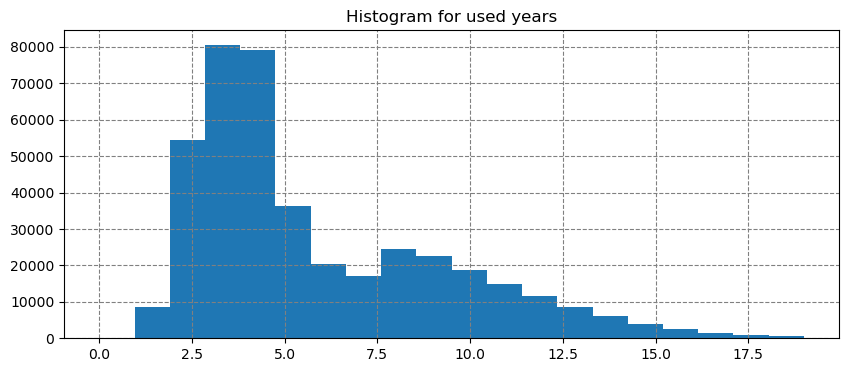

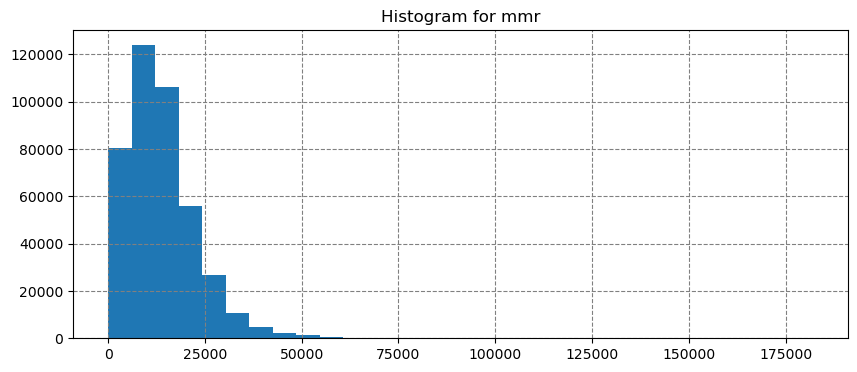

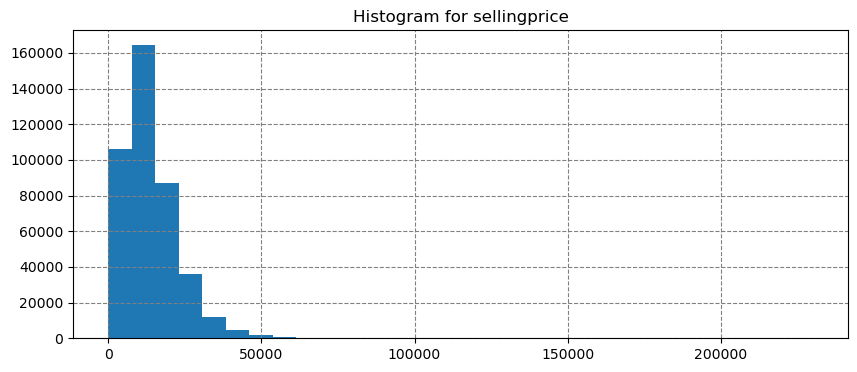

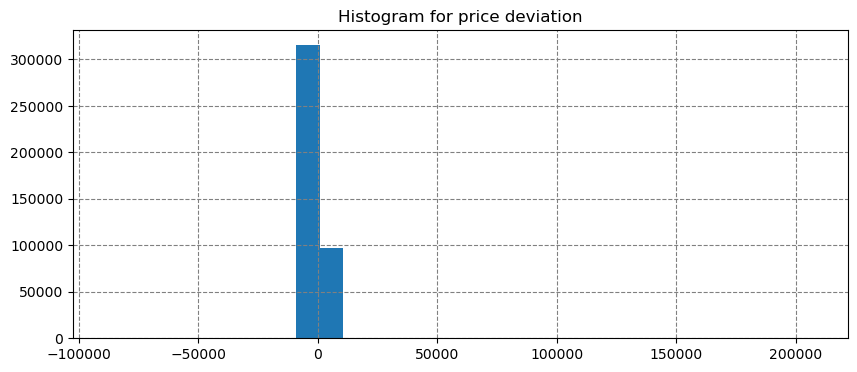

In [75]:
for column in df_num.columns:
    unique_values = df_num[column].nunique()
    bins = min(unique_values, 30)
    plt.figure(figsize=(10, 4))
    df_num[column].hist(bins=bins)
    plt.title(f'Histogram for {column}')
    plt.grid(True, which='both', linestyle='--', color='gray')
    plt.show()

In [77]:
for i in df_cat.columns:
    print(f"{i} OG: {df_cat[i].nunique()},",f"smaple: {df_sampled[i].nunique()}",'\n')

make OG: 53, smaple: 47 

model OG: 738, smaple: 571 

body OG: 45, smaple: 38 

transmission OG: 2, smaple: 2 

condition level OG: 4, smaple: 4 

color OG: 19, smaple: 19 

interior OG: 17, smaple: 17 

state OG: 34, smaple: 34 

seller OG: 11036, smaple: 3128 

saledate OG: 158, smaple: 134 



In [79]:
df_sampled['seller'].value_counts().head(60)

seller
ford motor credit company llc                    767
nissan-infiniti lt                               752
the hertz corporation                            733
santander consumer                               652
avis corporation                                 565
nissan infiniti lt                               458
wells fargo dealer services                      362
ahfc/honda lease trust/hvt  inc. eot             298
tdaf remarketing                                 295
ge fleet services for itself/servicer            280
enterprise veh exchange/rental                   259
jpmorgan chase bank n.a.                         258
chrysler capital                                 244
financial services remarketing (lease)           227
gm financial                                     226
hyundai motor finance                            225
dt credit corporation                            209
avis budget group                                207
ford motor credit company llc pd       

In [81]:
df_sampled.groupby('state')['transmission'].value_counts(normalize=True).head(60)

state  transmission
AL     automatic       1.000000
AZ     automatic       0.971098
       manual          0.028902
CA     automatic       0.962166
       manual          0.037834
CO     automatic       0.975694
       manual          0.024306
FL     automatic       0.978743
       manual          0.021257
GA     automatic       0.968944
       manual          0.031056
HI     automatic       0.968254
       manual          0.031746
IL     automatic       0.982394
       manual          0.017606
IN     automatic       0.977401
       manual          0.022599
LA     automatic       0.966102
       manual          0.033898
MA     automatic       0.946768
       manual          0.053232
MD     automatic       0.962865
       manual          0.037135
MI     automatic       0.975728
       manual          0.024272
MN     automatic       0.961039
       manual          0.038961
MO     automatic       0.982249
       manual          0.017751
MS     automatic       0.958333
       manual       

# Part 3

In [ ]:
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt

In [ ]:
sample_df = pd.read_excel('used_car_price.xlsx')

In [ ]:
color_counts = sample_df.groupby('color')['vin'].count()
color_proportions = ((color_counts / color_counts.sum()) * 100).round(2).sort_values(ascending=False)
print(color_proportions)


In [ ]:
sample_df

In [ ]:
# Create a "mask" for missing values
missing_mask = sample_df['color']== '—'

# Compare distributions of categorical feature (e.g., 'Education')
edu_missing_comparison = sample_df.groupby(missing_mask)['interior'].value_counts(normalize=True) * 100

# Display the comparison
edu_missing_comparison

In [ ]:
# Calculate the color counts and exclude '-'
color_counts = sample_df['color'].value_counts()
color_counts_without_dash = color_counts.drop('—')

# Calculate the proportions without '-'
color_proportions_without_dash = color_counts_without_dash / color_counts_without_dash.sum()

# Number of '-' rows to be distributed
num_dash_rows = color_counts['—']

# Calculate how many of the '-' rows should go to each color
distribution_counts = (color_proportions_without_dash * num_dash_rows).round().astype(int)

import numpy as np

# Get the indices of rows with color '-'
dash_indices = sample_df[sample_df['color'] == '—'].index

# Create a list of new color values for '-' rows
new_colors = []
for color, count in distribution_counts.items():
    new_colors.extend([color] * count)

# In case of rounding discrepancies, adjust the length of new_colors
new_colors = new_colors[:len(dash_indices)]

# Assign new colors to rows that previously had '-'
sample_df.loc[dash_indices, 'color'] = np.random.choice(new_colors, size=len(dash_indices), replace=False)

In [ ]:
color_counts = sample_df.groupby('color')['vin'].count()
color_proportions = ((color_counts / color_counts.sum()) * 100).round(2).sort_values(ascending=False)
print(color_proportions)

In [ ]:
sample_df